## Овечка и пастух

### **Спецификация среды «Овечка и пастух» (v2.0)**

**Агент (Собака-пастух):** Дискретный объект на сетке $N \times N$, обладающий координатами $(x, y)$ и способностью взаимодействовать с овечкой через действие «Лай».

**Цель (Овечка):** Динамический объект. В начале игры находится в случайной точке. При успешном «Лае» переходит в режим следования за собакой. Новой целью для всей группы становится Дом (загон).

---

#### **1. Состояние (State) — Вектор из 11 параметров:**
Для эффективного обучения данные нормализуются и дискретизируются:
1.  **Позиция собаки:** Координаты $(x, y)$ на сетке.
2.  **Дистанция до цели:** Евклидово расстояние до актуальной цели (овца или дом).
3.  **Угол до цели:** Угол в градусах относительно условного «севера» собаки (дискретизация на 8 направлений по 45°).
4.  **Статус поимки:** Бинарный флаг (0 — поиск овцы, 1 — овца поймана).
5.  **Статус контроля:** Бинарный флаг (0 — овца следует рядом, 1 — овца отстала/убегает).
6.  **Дистанция «Собака-Овца»:** Текущий разрыв между агентом и овечкой.
7.  **Радары (4 параметра):** Расстояние до ближайшего препятствия (забор или край поля) в направлениях: Вверх, Вниз, Влево, Вправо.

---

#### **2. Действия (Action):**
* **0, 1, 2, 3:** Движение (Вверх, Вниз, Влево, Вправо).
* **4: «Лай»:** Команда для подбора овечки или восстановления контроля. Эффективна только на дистанции $\le 1.5$ клеток.

---

#### **3. Система наград (Reward Shaping):**
Система сбалансирована так, чтобы исключить циклическое «накручивание» очков:

* **Глобальные цели:**
    * **+500:** Терминальное состояние (Победа). Собака и овечка одновременно зашли в Дом.
    * **+100:** Успешная поимка овечки (первый успешный «Лай»).
* **Направляющие стимулы (Hinting):**
    * **+0.05:** За каждое сокращение дистанции до актуальной цели (овечка или дом).
    * **-0.07:** За увеличение дистанции от актуальной цели.
    * **+50:** Восстановление потерянного контроля над овечкой.
* **Штрафы и ограничения:**
    * **-10:** Столкновение с препятствием (собака остается на месте).
    * **-20:** Потеря контроля (овечка «убежала» слишком далеко).
    * **-5:** Необоснованный лай (применение действия вдали от овцы).
    * **-1:** Штраф за каждый шаг (стимул к поиску кратчайшего пути).



---

#### **4. Условия завершения (Termination):**
1.  **Успех:** Координаты собаки и овечки совпадают с координатами дома.
2.  **Тайм-аут:** Исчерпан лимит шагов (например, 500 шагов), цель не достигнута.


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
import collections
import time

from gymnasium import spaces
from IPython.display import clear_output

In [3]:
class Sheep_And_Shepherd(gym.Env):
    def __init__(self, size=10):
        super().__init__()  # Наследование базовых функций среды Gymnasium
        self.size = size
        self.action_space = spaces.Discrete(5)  # Вперед, Назад, Поворот L, Поворот R, Лай

        # i. Положение (x, y) - 2 параметра
        # ii. Угол поворота - 1 параметр
        # iii. Расстояние до цели - 1 параметр
        # iv. Угол до цели относительно собаки - 1 параметр
        # v. Препятствия вблизи (4 направления) - 4 параметра
        # vi. статус "овца поймана" 

        # Границы зрения собаки (минимум и максимум)
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, -180, 0, 0, 0, 0, 0]),
            high=np.array([size-1, size-1, 360, size*1.5, 180, size, size, size, size, 1]),
            dtype=np.float32
        )

        self.grid = np.zeros((size, size), dtype=int)
        self.home_pos = np.array([size - 1, size - 1])
        self.grid[self.home_pos[0], self.home_pos[1]] = 2

        for i in range(2, 5): self.grid[i, 3] = 1
        for i in range(6, 10): self.grid[i, 1] = 1
        for i in range(6, 9): self.grid[i, 7] = 1
        for i in range(3, 5): self.grid[i, 9] = 1

        for i in range(7, 9): self.grid[1, i] = 1
        for i in range(0, 2): self.grid[2, i] = 1
        for i in range(5, 8): self.grid[4, i] = 1
        for i in range(2, 4): self.grid[7, i] = 1
        
    
    def _get_obs(self):

        if self.has_sheep and not self.control_lost:
            target = self.home_pos
        else:
            target = self.sheep_pos
        
        dist_to_target = np.linalg.norm(self.dog_pos - target)
        dist_dog_sheep = np.linalg.norm(self.dog_pos - self.sheep_pos)
        
        target_vec = target - self.dog_pos
        target_angle = np.degrees(np.arctan2(target_vec[0], target_vec[1]))
        
        obstacles = self._scan_obstacles()

        return np.array([
            self.dog_pos[0], self.dog_pos[1],     # 0, 1: Позиция
            dist_to_target,                       # 2: Дистанция до цели
            target_angle,                         # 3: Угол
            float(self.has_sheep),                # 4: Статус поимки
            float(self.control_lost),             # 5: Статус контроля
            dist_dog_sheep,                       # 6: Дистанция собака-овца
            *obstacles                            # 7, 8, 9, 10: Радары (4 шт)
        ], dtype=np.float32)
    
    def _scan_obstacles(self):
        distances = []
        for delta_row, delta_column in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            d = 0
            curr = self.dog_pos.copy()
           
            for _ in range(self.size): 
                curr[0] += delta_row
                curr[1] += delta_column

                if not (0 <= curr[0] < self.size and 0 <= curr[1] < self.size) or \
                   self.grid[curr[0], curr[1]] == 1:
                    break
                d += 1
            distances.append(float(d))
        return distances

    def reset(self, seed=81, options=None):
        super().reset(seed=seed)
        
        self.dog_pos = np.array([0, 0], dtype=np.int32)
        self.has_sheep = False
        self.control_lost = False
        
        while True:
            self.sheep_pos = np.array([random.randint(0, self.size-1), random.randint(0, self.size-1)])

            if self.grid[self.sheep_pos[0], self.sheep_pos[1]] == 0 and \
               not np.array_equal(self.sheep_pos, self.dog_pos):
                break
                
        return self._get_obs(), {}  

    def step(self, action):
        reward = -1  
        terminated = False
        
        old_dog_pos = self.dog_pos.copy()

        if action == 0: self.dog_pos[0] -= 1 # Вверх
        elif action == 1: self.dog_pos[0] += 1 # Вниз
        elif action == 2: self.dog_pos[1] -= 1 # Влево
        elif action == 3: self.dog_pos[1] += 1 # Вправо 
        
        if not (0 <= self.dog_pos[0] < self.size and 0 <= self.dog_pos[1] < self.size) or \
           self.grid[self.dog_pos[0], self.dog_pos[1]] == 1:
            self.dog_pos = old_dog_pos
            reward -= 10 

        if action == 4:
            d_dog_sheep = np.linalg.norm(self.dog_pos - self.sheep_pos)
            if d_dog_sheep <= 1.5:
                if not self.has_sheep:
                    self.has_sheep = True
                    reward += 100 
                elif self.control_lost:
                    self.control_lost = False
                    reward += 15 
            else:
                reward -= 5

        if self.has_sheep:
            d_dog_sheep = np.linalg.norm(self.dog_pos - self.sheep_pos)
            
            if d_dog_sheep > 1.5 and not self.control_lost:
                self.control_lost = True
                reward -= 20
            
            if not self.control_lost:
                if random.random() <= 0.1: 
                    self._move_sheep_randomly()
                else:
                    self.sheep_pos = old_dog_pos.copy()
            else:
                self._move_sheep_randomly()

        dog_at_home = np.array_equal(self.dog_pos, self.home_pos)
        sheep_at_home = np.array_equal(self.sheep_pos, self.home_pos)

        if dog_at_home and sheep_at_home:
            reward += 500 
            terminated = True
        elif dog_at_home and not self.has_sheep:
            reward -= 10 

        return self._get_obs(), reward, terminated, False, {}

    def _move_sheep_randomly(self):
        move = random.choice([[-1,0], [1,0], [0,-1], [0,1], [0,0]])
        new_s = self.sheep_pos + move
        if 0 <= new_s[0] < self.size and 0 <= new_s[1] < self.size:
            if self.grid[new_s[0], new_s[1]] == 0:
                self.sheep_pos = new_s

    def render(self):
        output = ""
        for r in range(self.size):
            row = []
            for c in range(self.size):
                curr = [r, c]

                if np.array_equal(self.dog_pos, curr):
                    row.append("🐕")
                elif np.array_equal(self.sheep_pos, curr):
                    row.append("🐑")
                elif np.array_equal(self.home_pos, curr):
                    row.append("🏠")
                elif self.grid[r, c] == 1:
                    row.append("🚧")
                else:
                    row.append("🌱")
            output += " ".join(row) + "\n"
        
        print(output)
        
        status = "Ищем овечку"
        if self.has_sheep:
            
            if not self.control_lost: 
                status = "Ведем овечку домой" 
            else:
                "Овечка убежала!"
        if np.array_equal(self.dog_pos, self.home_pos) and np.array_equal(self.sheep_pos, self.home_pos):
            status = "Все дома! 🎉"
            
        print(f"Статус: {status}")

In [4]:
class QLearningAgent:
    def __init__(self, action_space, alpha=0.1, gamma=0.9, epsilon=1.0):
        self.q_table = collections.defaultdict(lambda: np.zeros(action_space.n))
        self.alpha = alpha  # Скорость обучения
        self.gamma = gamma  # Коэффициент дисконтирования
        self.epsilon = epsilon  # Шанс случайного действия
        self.epsilon_decay = 0.9995 
        self.min_epsilon = 0.05

    def discretize_obs(self, obs):
        res = [int(obs[0]), int(obs[1])] 
        res.append(int(obs[2] // 2))
        res.append(int(obs[3] // 45))
        res.append(int(obs[4]))
        res.append(int(obs[5]))
        res.append(int(obs[6] // 2))
        res.extend([int(o) for o in obs[7:11]])
        
        return tuple(res)

    def choose_action(self, obs):
        state = self.discretize_obs(obs)
        if random.random() < self.epsilon:
            return random.randint(0, 4)
        return np.argmax(self.q_table[state]) 

    def learn(self, obs, action, reward, next_obs):
        state = self.discretize_obs(obs)
        next_state = self.discretize_obs(next_obs)
        
        old_value = self.q_table[state][action]
        next_max = np.max(self.q_table[next_state])
        
        new_value = old_value + self.alpha * (reward + self.gamma * next_max - old_value)
        self.q_table[state][action] = new_value
        
        if self.epsilon > self.min_epsilon:
            self.epsilon *= self.epsilon_decay

In [5]:
env = Sheep_And_Shepherd(size=10)
agent = QLearningAgent(env.action_space)
episode_rewards = []

for episode in range(10_000):
    obs, info = env.reset()
    total_reward = 0
    done = False
    step_count = 0 
    
    while not done and step_count < 500: 
        action = agent.choose_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        agent.learn(obs, action, reward, next_obs)
        
        obs = next_obs
        total_reward += reward
        done = terminated or truncated
        step_count += 1 
        
    episode_rewards.append(total_reward)
    
    if (episode + 1) % 500 == 0:
        print(f"Эпизод {episode+1}, Награда: {np.mean(episode_rewards[-100:]):.1f}, Epsilon: {agent.epsilon:.2f}")

/Users/irinaaristova/Documents/Programming/practical-workshop-term-4/venv/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Эпизод 500, Награда: -307.8, Epsilon: 0.05
Эпизод 1000, Награда: 210.0, Epsilon: 0.05
Эпизод 1500, Награда: 472.5, Epsilon: 0.05
Эпизод 2000, Награда: 468.8, Epsilon: 0.05
Эпизод 2500, Награда: 481.3, Epsilon: 0.05
Эпизод 3000, Награда: 455.6, Epsilon: 0.05
Эпизод 3500, Награда: 496.4, Epsilon: 0.05
Эпизод 4000, Награда: 479.5, Epsilon: 0.05
Эпизод 4500, Награда: 469.2, Epsilon: 0.05
Эпизод 5000, Награда: 491.1, Epsilon: 0.05
Эпизод 5500, Награда: 492.8, Epsilon: 0.05
Эпизод 6000, Награда: 486.9, Epsilon: 0.05
Эпизод 6500, Награда: 488.6, Epsilon: 0.05
Эпизод 7000, Награда: 514.1, Epsilon: 0.05
Эпизод 7500, Награда: 513.9, Epsilon: 0.05
Эпизод 8000, Награда: 489.5, Epsilon: 0.05
Эпизод 8500, Награда: 509.6, Epsilon: 0.05
Эпизод 9000, Награда: 504.7, Epsilon: 0.05
Эпизод 9500, Награда: 523.5, Epsilon: 0.05
Эпизод 10000, Награда: 513.6, Epsilon: 0.05


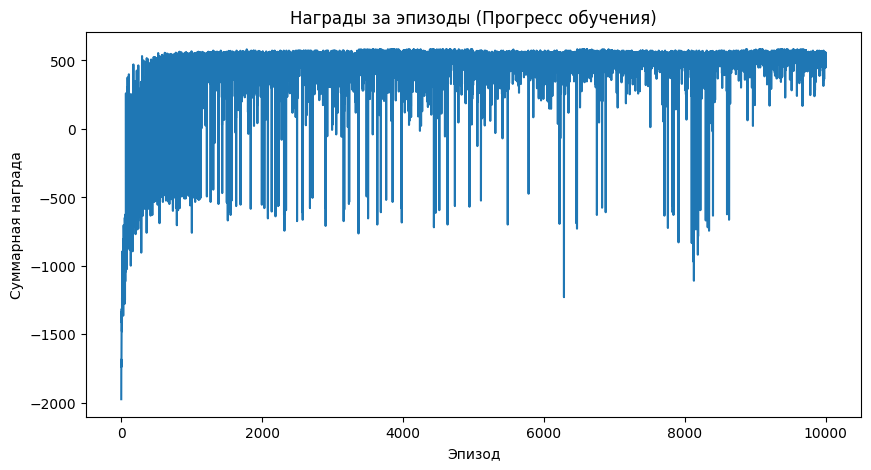

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.title("Награды за эпизоды (Прогресс обучения)")
plt.xlabel("Эпизод")
plt.ylabel("Суммарная награда")
plt.show()

In [8]:
agent.epsilon = 0 
obs, info = env.reset()
done = False
step = 0

try:
    while not done and step < 100:
        clear_output(wait=True)

        state = agent.discretize_obs(obs)
        action = np.argmax(agent.q_table[state])
        
        obs, reward, terminated, truncated, info = env.step(action)
        
        print(f"Шаг №{step} | Действие: {action} | Награда за ход: {reward}")
        env.render()
        
        time.sleep(0.3)
        
        step += 1
        done = terminated or truncated

    if done:
        print("🎉 Овечка доставлена! Миссия выполнена.")
    else:
        print("⏳ Лимит шагов исчерпан.")

except KeyboardInterrupt:
    print("Тест остановлен пользователем.")

Шаг №37 | Действие: 1 | Награда за ход: 489
🌱 🌱 🌱 🌱 🌱 🌱 🌱 🌱 🌱 🌱
🌱 🌱 🌱 🌱 🌱 🌱 🌱 🚧 🚧 🌱
🚧 🚧 🌱 🚧 🌱 🌱 🌱 🌱 🌱 🌱
🌱 🌱 🌱 🚧 🌱 🌱 🌱 🌱 🌱 🚧
🌱 🌱 🌱 🚧 🌱 🚧 🚧 🚧 🌱 🚧
🌱 🌱 🌱 🌱 🌱 🌱 🌱 🌱 🌱 🌱
🌱 🚧 🌱 🌱 🌱 🌱 🌱 🚧 🌱 🌱
🌱 🚧 🚧 🚧 🌱 🌱 🌱 🚧 🌱 🌱
🌱 🚧 🌱 🌱 🌱 🌱 🌱 🚧 🌱 🌱
🌱 🚧 🌱 🌱 🌱 🌱 🌱 🌱 🌱 🐕

Статус: Все дома! 🎉
🎉 Овечка доставлена! Миссия выполнена.
